In [69]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sqlite3
from shapely.geometry import box
from geopandas import clip
import warnings

warnings.filterwarnings('ignore')

DB_PATH = "bosch_dw.db"
GEOJSON  = "countries.geojson"

PLOT_COLOR_BLUE = "#4a90e2"
PLOT_COLOR_RED = "#ed1919"

In [70]:
with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql("""
        SELECT country, COUNT(*) AS n_reviews, AVG(rating) AS avg_rating
        FROM fact_review
        WHERE country IS NOT NULL
        GROUP BY country
    """, conn)

world = gpd.read_file(GEOJSON)
world = world.rename(columns={"ISO3166-1-Alpha-2": "country"})

europe_bbox = gpd.GeoDataFrame(
    geometry=[box(-25, 34, 45, 72)],
    crs=world.crs
)

world = clip(world, europe_bbox)

# paesi con dati
europe = world[world["country"].isin(df["country"])].merge(df, on="country", how="left")

# paesi europei di contorno (sfondo)
all_europe_iso2 = [
    "AL","AD","AT","BY","BE","BA","BG","HR","CY","CZ","DK","EE","FI",
    "FR","DE","GR","HU","IS","IE","IT","XK","LV","LI","LT","LU","MT",
    "MD","MC","ME","NL","MK","NO","PL","PT","RO","RU","SM","RS","SK",
    "SI","ES","SE","CH","UA","GB","VA","TR"
]
background = world[world["country"].isin(all_europe_iso2)]

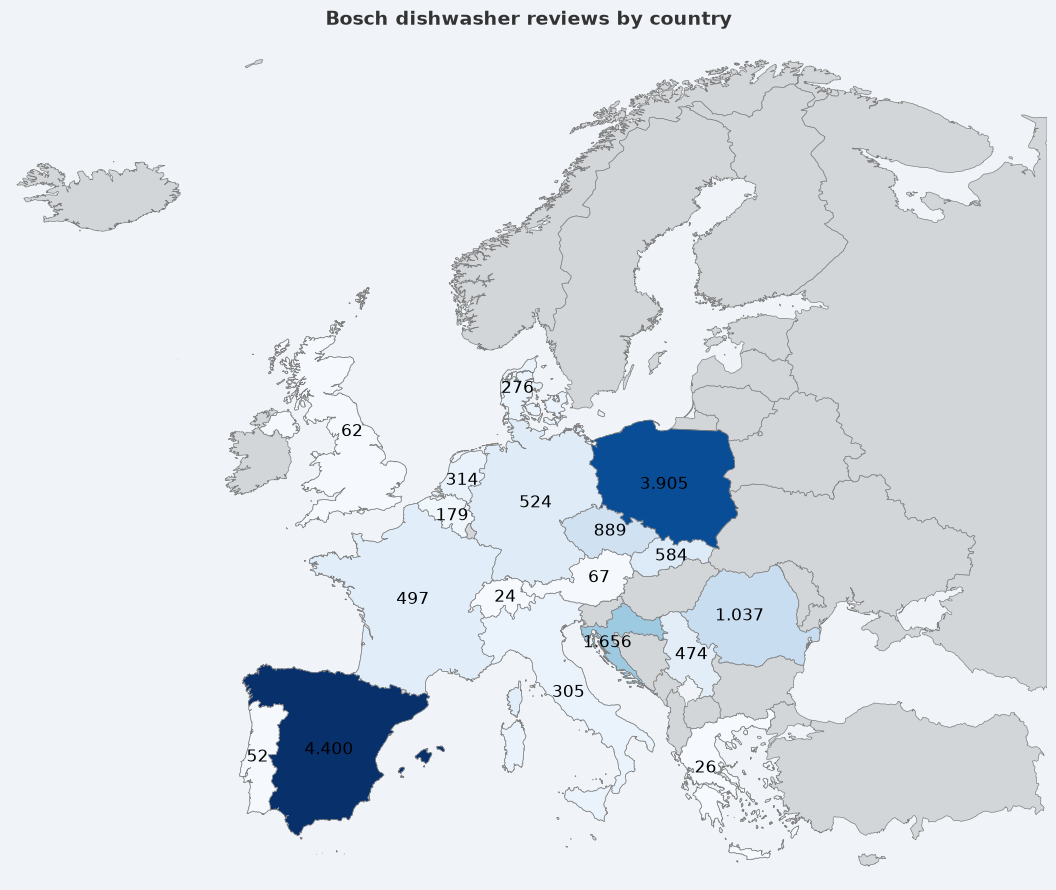

In [71]:
fig, ax = plt.subplots(figsize=(12, 9))
ax.set_facecolor("#f0f4f8")
fig.patch.set_facecolor("#f0f4f8")

background.plot(ax=ax, color="#d3d6d9", edgecolor="gray", linewidth=0.5)
europe.plot(
    column="n_reviews",
    ax=ax,
    cmap="Blues",
    edgecolor="gray",
    linewidth=0.5,
    vmin=0,
    vmax=df["n_reviews"].max(),
)

for _, row in europe.iterrows():
    if pd.isna(row["n_reviews"]):
        continue
    pt = row["geometry"].representative_point()
    label = f"{int(row['n_reviews']):,}".replace(",", ".")
    ax.annotate(
        label, xy=(pt.x, pt.y),
        ha="center", va="center",
        fontsize=12, color="black",
    )

ax.set_xlim(-25, 45)
ax.set_ylim(34, 72)
ax.axis("off")
ax.set_title("Bosch dishwasher reviews by country", fontsize=14, pad=12, color="#333", fontweight="bold")

plt.tight_layout()
plt.savefig("bosch_map.png", dpi=150, bbox_inches="tight")
plt.show()

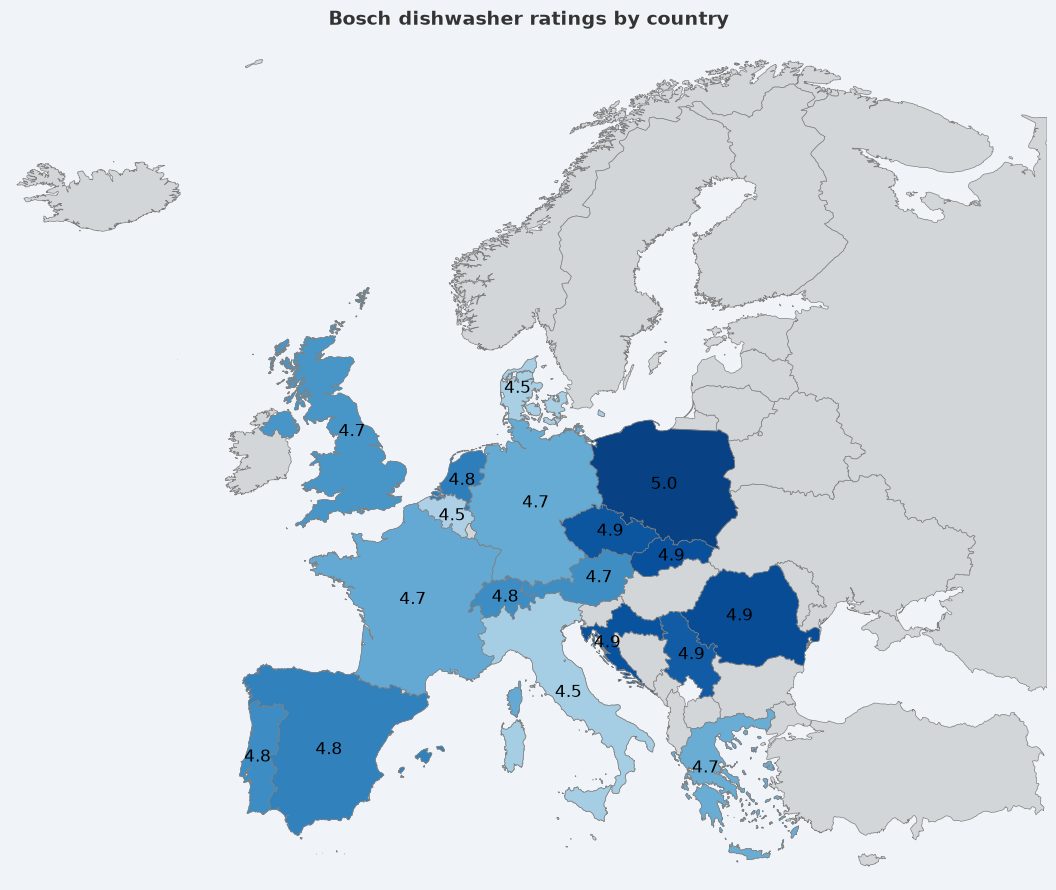

In [72]:
fig, ax = plt.subplots(figsize=(12, 9))
ax.set_facecolor("#f0f4f8")
fig.patch.set_facecolor("#f0f4f8")

background.plot(ax=ax, color="#d3d6d9", edgecolor="gray", linewidth=0.5)
europe.plot(
    column="avg_rating",
    ax=ax,
    cmap="Blues",
    edgecolor="gray",
    linewidth=0.5,
    vmin=4.3,
    vmax=5,
)

for _, row in europe.iterrows():
    if pd.isna(row["avg_rating"]):
        continue
    pt = row["geometry"].representative_point()
    label = f"{row['avg_rating']:.1f}"
    ax.annotate(
        label, xy=(pt.x, pt.y),
        ha="center", va="center",
        fontsize=12, color="black",
    )

ax.set_xlim(-25, 45)
ax.set_ylim(34, 72)
ax.axis("off")
ax.set_title("Bosch dishwasher ratings by country", fontsize=14, pad=12, color="#333", fontweight="bold")

plt.tight_layout()
plt.savefig("bosch_map.png", dpi=150, bbox_inches="tight")
plt.show()

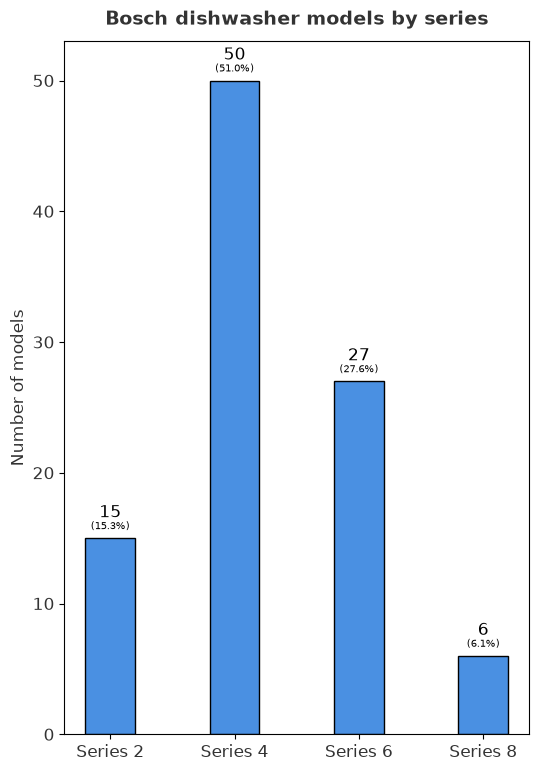

In [73]:
with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql("""
        SELECT serie, COUNT(*) AS n_models
        FROM dim_product
        WHERE serie IS NOT NULL
        GROUP BY serie
    """, conn)

df["serie"] = df["serie"].apply(lambda x: "Series "+ x[-1])

tot_models = df["n_models"].sum()

_, ax = plt.subplots(figsize=(6, 9))
#ax.grid(axis="both", linestyle="--", alpha=0.5)
bars = plt.bar(df["serie"], df["n_models"], color=PLOT_COLOR_BLUE, width=0.4, edgecolor="black")

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 1.3, f"{h}", ha= "center", va="bottom",
        fontsize = 12, color = "black"
    )
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.5, f"({h/tot_models*100:.1f}%)", ha= "center", va="bottom",
        fontsize = 7.5, color = "black"
    )


ax.set_title("Bosch dishwasher models by series", fontsize=14, pad=12, color="#333", fontweight="bold")
ax.set_ylabel("Number of models", fontsize=12, color="#333")
ax.set_ylim([0, 53])
ax.tick_params(axis="x", labelsize=12, labelcolor="#333")
ax.tick_params(axis="y", labelsize=12, labelcolor="#333")


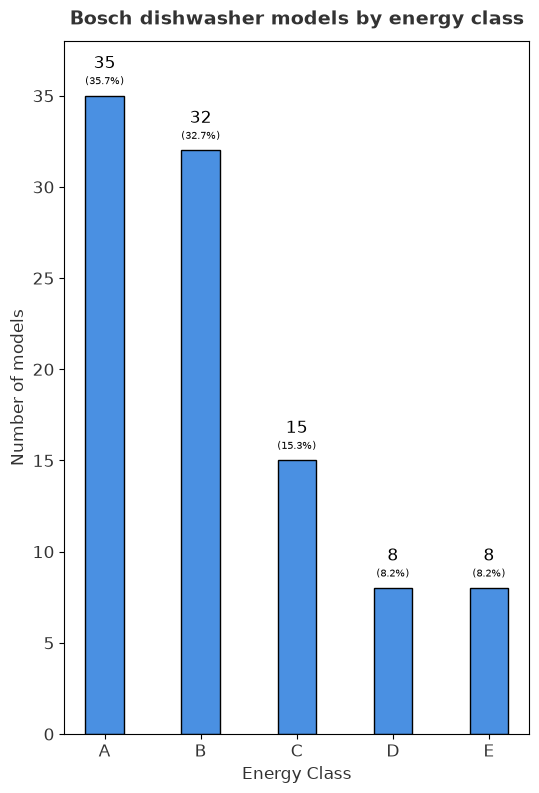

In [74]:
with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql("""
        SELECT energy_class, COUNT(*) AS n_models
        FROM dim_product
        WHERE energy_class IS NOT NULL
        GROUP BY energy_class
    """, conn)

_, ax = plt.subplots(figsize=(6, 9))
bars = plt.bar(df["energy_class"], df["n_models"], color=PLOT_COLOR_BLUE, width=0.4, edgecolor="black")

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 1.3, f"{h}", ha= "center", va="bottom",
        fontsize = 12, color = "black"
    )
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.5, f"({h/tot_models*100:.1f}%)", ha= "center", va="bottom",
        fontsize = 7.5, color = "black"
    )

ax.set_title("Bosch dishwasher models by energy class", fontsize=14, pad=12, color="#333", fontweight="bold")
ax.set_ylim([0, 38])
ax.set_xlabel("Energy Class", fontsize=12, color="#333")
ax.set_ylabel("Number of models", fontsize=12, color="#333")
ax.tick_params(axis="x", labelsize=12, labelcolor="#333")
ax.tick_params(axis="y", labelsize=12, labelcolor="#333")


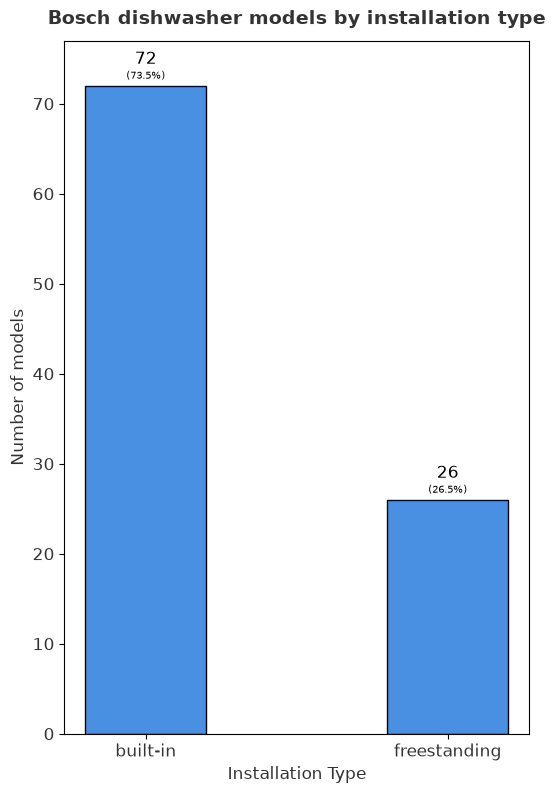

In [75]:
with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql("""
        SELECT install_type, COUNT(*) AS n_models
        FROM dim_product
        WHERE install_type IS NOT NULL
        GROUP BY install_type
    """, conn)

_, ax = plt.subplots(figsize=(6, 9))
bars = plt.bar(df["install_type"], df["n_models"], color=PLOT_COLOR_BLUE, width=0.4, edgecolor="black")

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 2, f"{h}", ha= "center", va="bottom",
        fontsize = 12, color = "black"
    )
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.5, f"({h/tot_models*100:.1f}%)", ha= "center", va="bottom",
        fontsize = 7.5, color = "black"
    )

ax.set_title("Bosch dishwasher models by installation type", fontsize=14, pad=12, color="#333", fontweight="bold")
ax.set_xlabel("Installation Type", fontsize=12, color="#333")
ax.set_ylabel("Number of models", fontsize=12, color="#333")
ax.set_ylim([0, 77])
ax.tick_params(axis="x", labelsize=12, labelcolor="#333")
ax.tick_params(axis="y", labelsize=12, labelcolor="#333")

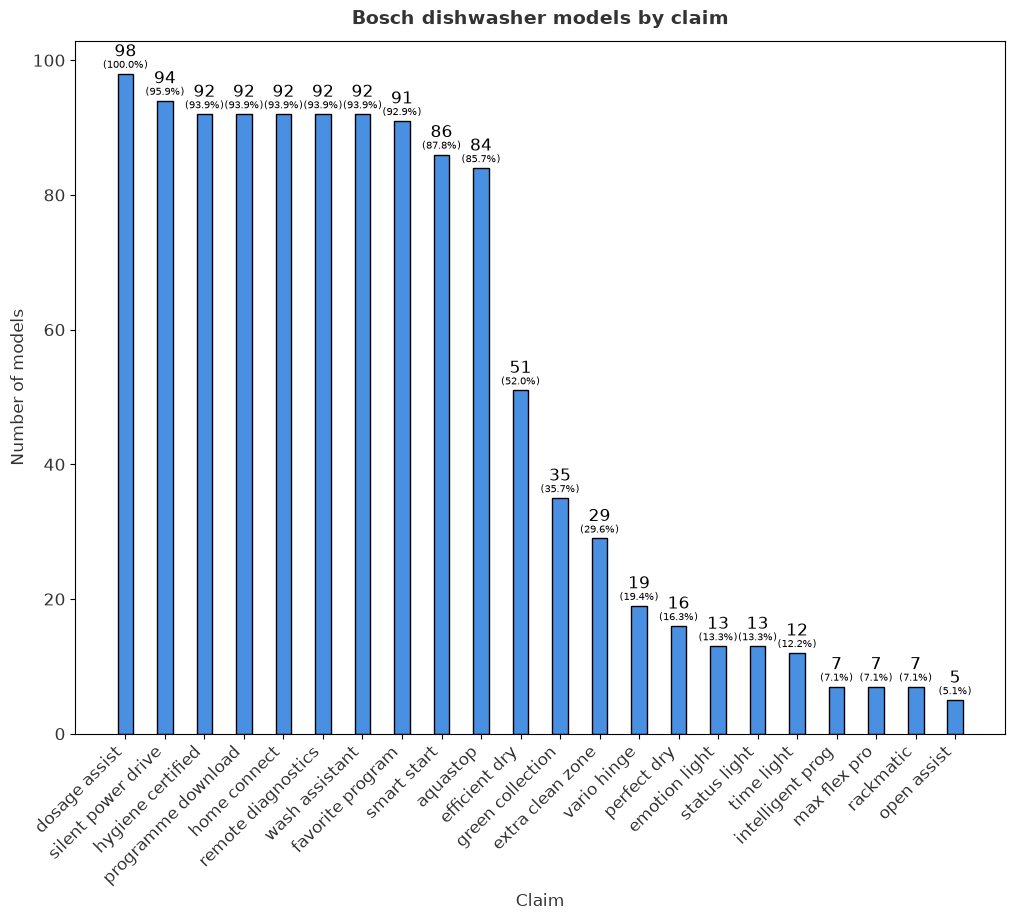

In [76]:
rows = []

with sqlite3.connect(DB_PATH) as conn:
    cols = pd.read_sql("PRAGMA table_info(dim_product);", conn)

    for idx, col in enumerate(cols[cols["name"].str.startswith("has_")]["name"]):
        df_temp = pd.read_sql(f"""
            SELECT COUNT(*) AS n_{col}
            FROM dim_product
            WHERE {col} = 1 AND is_discontinued = False
        """, conn)

        rows.append({
            "claim": col[4:],
            "n_models": df_temp.iloc[0, 0]
        })

    df = pd.DataFrame(rows).sort_values(ascending=False , by="n_models")

_, ax = plt.subplots(figsize=(12, 9))
bars = plt.bar(df["claim"].apply(lambda x: x.replace("_"," ")), df["n_models"], color=PLOT_COLOR_BLUE, width=0.4, edgecolor="black")

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 2, f"{h}", ha= "center", va="bottom",
        fontsize = 12, color = "black"
    )
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.5, f"({h/tot_models*100:.1f}%)", ha= "center", va="bottom",
        fontsize = 7.5, color = "black"
    )

ax.set_title("Bosch dishwasher models by claim", fontsize=14, pad=12, color="#333", fontweight="bold")
ax.set_xlabel("Claim", fontsize=12, color="#333")
ax.set_ylabel("Number of models", fontsize=12, color="#333")
ax.tick_params(axis="x", labelsize=12, labelcolor="#333", labelrotation=45)
plt.setp(ax.get_xticklabels(), ha="right")
ax.tick_params(axis="y", labelsize=12, labelcolor="#333")

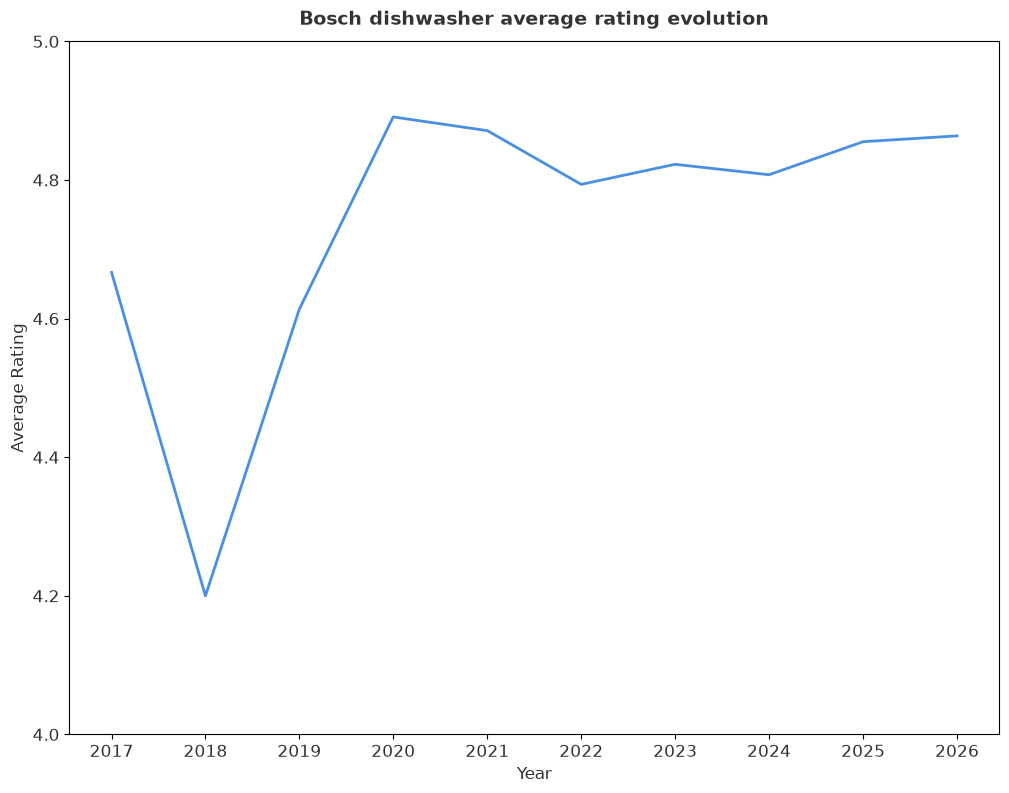

In [77]:
import datetime

with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql("""
        SELECT year, AVG(rating) AS avg_rating
        FROM fact_review
        WHERE rating IS NOT NULL AND rating > 0
        GROUP BY year
        ORDER BY year
    """, conn)

df["date"] = df.apply(lambda x: datetime.date(int(x["year"]), 1, 1), axis=1)

_, ax = plt.subplots(figsize=(12, 9))
ax.plot(df["date"], df["avg_rating"], color=PLOT_COLOR_BLUE, linewidth=2)

ax.set_title("Bosch dishwasher average rating evolution", fontsize=14, pad=12, color="#333", fontweight="bold")
ax.set_xlabel("Year", fontsize=12, color="#333")
ax.set_ylabel("Average Rating", fontsize=12, color="#333")
ax.set_ylim([4, 5])
ax.tick_params(axis="x", labelsize=12, labelcolor="#333")
ax.tick_params(axis="y", labelsize=12, labelcolor="#333")

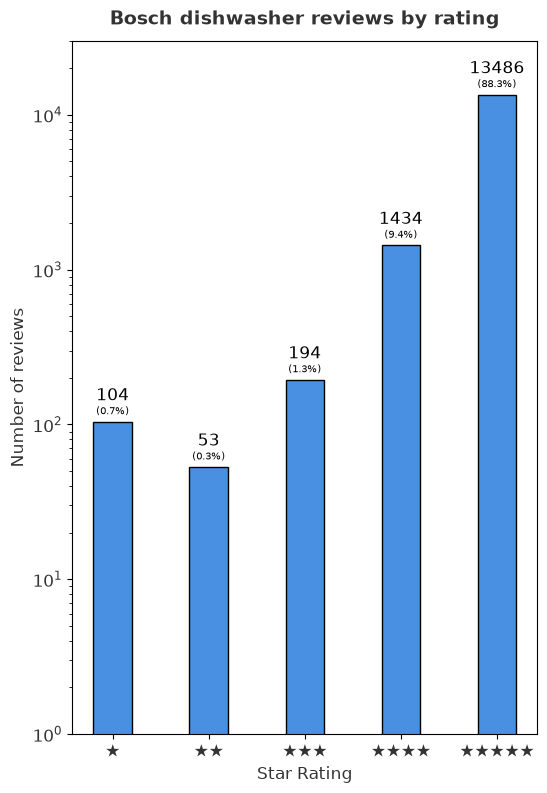

In [78]:
with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql("""
        SELECT rating, COUNT(*) AS n_reviews
        FROM fact_review
        WHERE rating IS NOT NULL AND rating > 0
        GROUP BY rating
        ORDER BY rating
    """, conn)

tot_reviews = df["n_reviews"].sum()

star = '\u2605'
df["rating"] = df["rating"].apply(lambda x: f"{star * int(x)}")

_, ax = plt.subplots(figsize=(6, 9))
bars = plt.bar(df["rating"], df["n_reviews"], color=PLOT_COLOR_BLUE, width=0.4, edgecolor="black")

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h*1.3, f"{h}", ha= "center", va="bottom",
        fontsize = 12, color = "black"
    )
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h*1.08, f"({h/tot_reviews*100:.1f}%)", ha= "center", va="bottom",
        fontsize = 7.5, color = "black"
    )

ax.set_title("Bosch dishwasher reviews by rating", fontsize=14, pad=12, color="#333", fontweight="bold")
ax.set_xlabel("Star Rating", fontsize=12, color="#333")
ax.set_ylabel("Number of reviews", fontsize=12, color="#333")
ax.set_yscale("log")
ax.set_ylim([1, 30000])
ax.tick_params(axis="x", labelsize=12, labelcolor="#333")
ax.tick_params(axis="y", labelsize=12, labelcolor="#333")

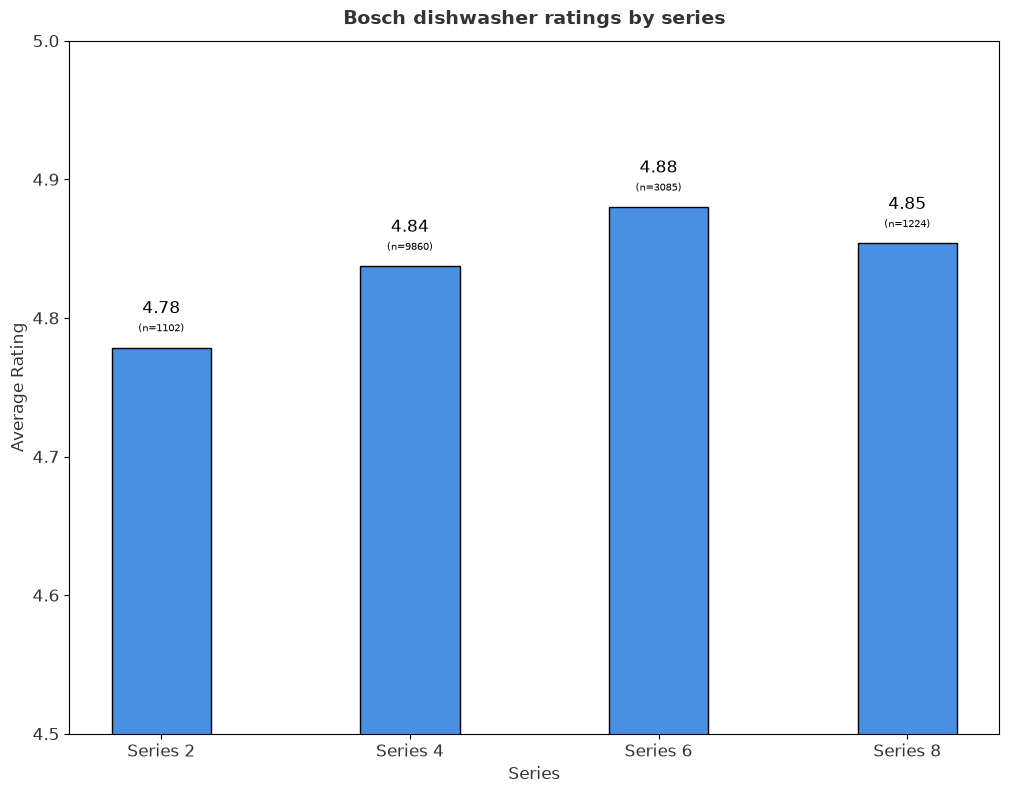

In [79]:
with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql("""
        SELECT serie, AVG(rating) AS avg_rating, COUNT(*) AS n_reviews
        FROM fact_review JOIN dim_product ON fact_review.product_id = dim_product.product_id
        WHERE rating IS NOT NULL AND rating > 0
        GROUP BY serie
        ORDER BY serie
    """, conn)

df["serie"] = df["serie"].apply(lambda x: "Series "+ x[-1])

_, ax = plt.subplots(figsize=(12, 9))
bars = plt.bar(df["serie"], df["avg_rating"], color=PLOT_COLOR_BLUE, width=0.4, edgecolor="black")

for idx, bar in enumerate(bars):
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.022, f"{h:.2f}", ha= "center", va="bottom",
        fontsize = 12, color = "black"
    )
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.01, f"(n={df.iloc[idx]['n_reviews']})", ha= "center", va="bottom",
        fontsize = 7.5, color = "black"
    )

ax.set_title("Bosch dishwasher ratings by series", fontsize=14, pad=12, color="#333", fontweight="bold")
ax.set_xlabel("Series", fontsize=12, color="#333")
ax.set_ylabel("Average Rating", fontsize=12, color="#333")
ax.set_ylim([4.5, 5])
ax.tick_params(axis="x", labelsize=12, labelcolor="#333")
ax.tick_params(axis="y", labelsize=12, labelcolor="#333")

Text(0.5, 1.0, 'Bosch dishwasher reviewers age distribution')

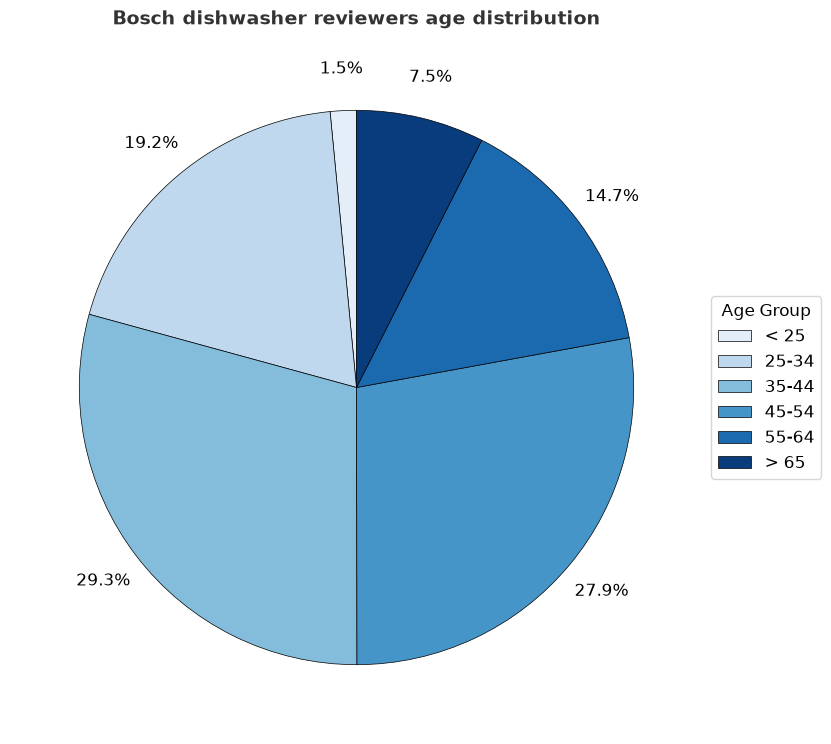

In [80]:
with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql("""
        SELECT age_midpoint AS age, COUNT(*) AS n_reviews
        FROM fact_review
        WHERE age IS NOT NULL
        GROUP BY age_midpoint
    """, conn)

AGE_DICT = {
    21: "< 25",
    29: "25-34",
    39: "35-44",
    49: "45-54",
    59: "55-64",
    68: "> 65"
}

df["age"] = df["age"].replace({15: 21})
df = df.groupby("age", as_index=False).sum().sort_values(by="age")

_, ax = plt.subplots(figsize=(12, 9))
ax.pie(df["n_reviews"], labels=None, autopct="%1.1f%%", pctdistance=1.15, startangle=90, colors=plt.cm.Blues(np.linspace(0.1, 0.95, len(df))),
       textprops={"fontsize": 12}, wedgeprops={"edgecolor": "black", "linewidth": 0.5})

ax.legend(df["age"].apply(lambda x: AGE_DICT[x]), title="Age Group", title_fontsize=12, fontsize=12, loc="center left", bbox_to_anchor=(1, 0.5))
ax.set_title("Bosch dishwasher reviewers age distribution", fontsize=14, pad=12, color="#333", fontweight="bold")

Text(0.5, 1.0, 'Bosch dishwasher usage distribution')

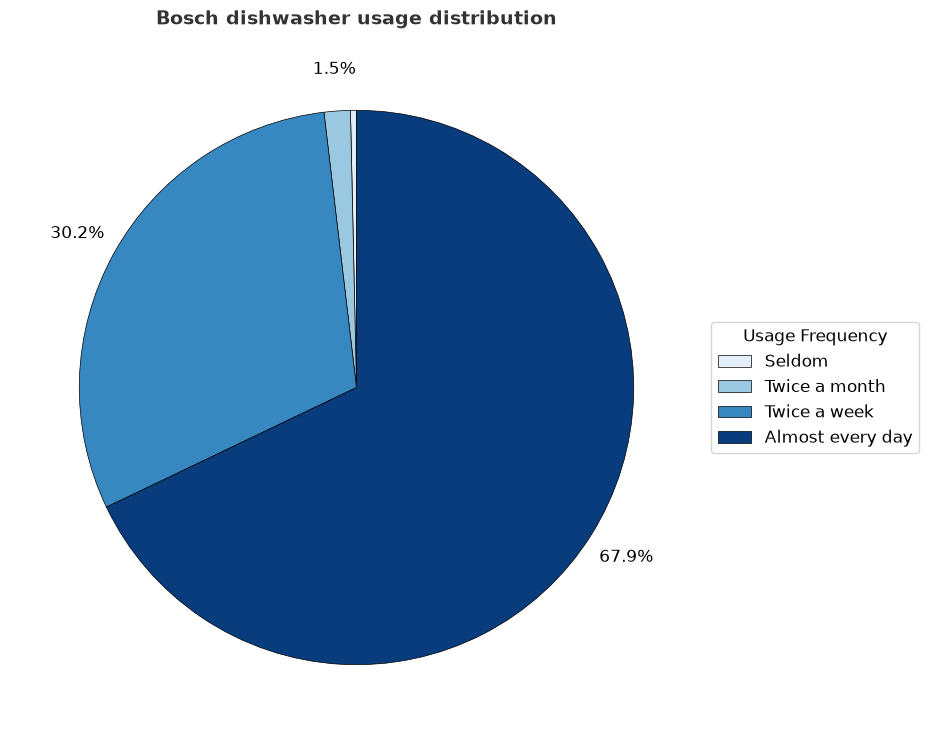

In [81]:
with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql("""
        SELECT usage_weekly AS usage, COUNT(*) AS n_reviews
        FROM fact_review
        WHERE usage_weekly IS NOT NULL
        GROUP BY usage_weekly
    """, conn)

df.head(10)

USAGE_DICT = {
    7: "Almost every day",
    2.5: "Twice a week",
    0.5: "Twice a month",
    0.1: "Seldom"
}

def autpct(pct):
    return f"{pct:.1f}%" if pct > 1 else ""

_, ax = plt.subplots(figsize=(12, 9))
ax.pie(df["n_reviews"], labels=None, autopct=autpct, pctdistance=1.15, startangle=90, colors=plt.cm.Blues(np.linspace(0.1, 0.95, len(df))),
       textprops={"fontsize": 12}, wedgeprops={"edgecolor": "black", "linewidth": 0.5})

ax.legend(df["usage"].apply(lambda x: USAGE_DICT[x]), title="Usage Frequency", title_fontsize=12, fontsize=12, loc="center left", bbox_to_anchor=(1, 0.5))
ax.set_title("Bosch dishwasher usage distribution", fontsize=14, pad=12, color="#333", fontweight="bold")

Text(0.5, 1.0, 'Bosch dishwasher user household distribution')

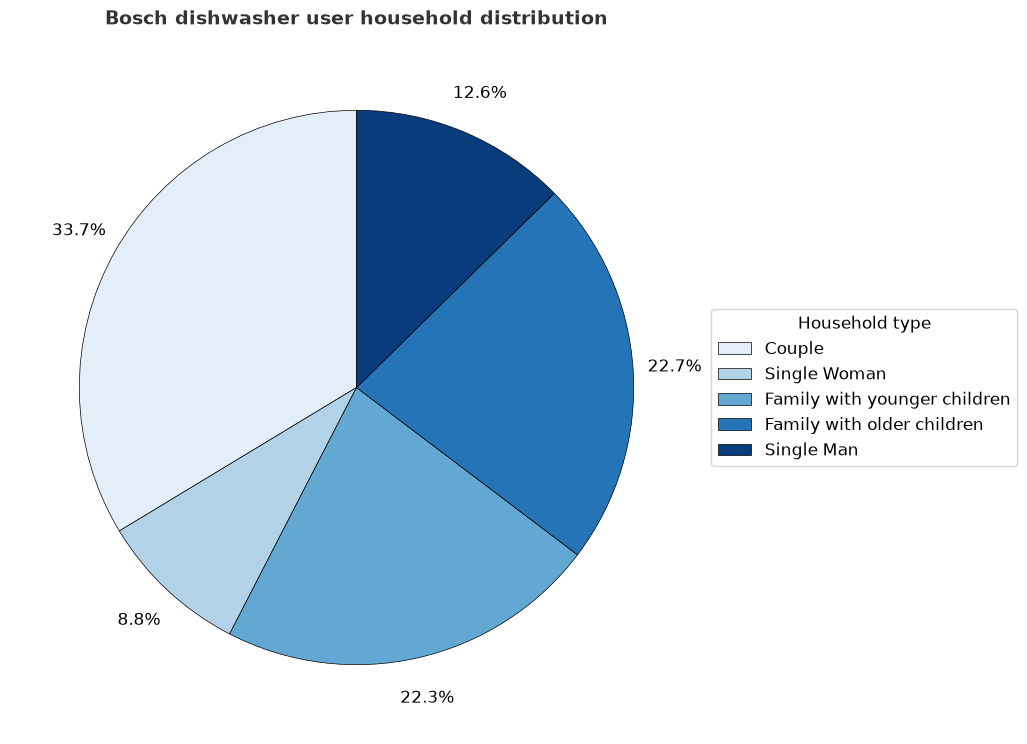

In [82]:
with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql("""
        SELECT household, COUNT(*) AS n_reviews
        FROM fact_review
        WHERE household IS NOT NULL
        GROUP BY household
    """, conn)

HOUSEHOLD_DICT = {
    "coppia": "Couple",
    "donna": "Single Woman",
    "uomo": "Single Man",
    "famiglia con figli piccoli": "Family with younger children",
    "famiglia con figli più grandi": "Family with older children",
}

_, ax = plt.subplots(figsize=(12, 9))
ax.pie(df["n_reviews"], labels=None, autopct="%1.1f%%", pctdistance=1.15, startangle=90, colors=plt.cm.Blues(np.linspace(0.1, 0.95, len(df))),
       textprops={"fontsize": 12}, wedgeprops={"edgecolor": "black", "linewidth": 0.5})

ax.legend(df["household"].apply(lambda x: HOUSEHOLD_DICT[x]), title="Household type", title_fontsize=12, fontsize=12, loc="center left", bbox_to_anchor=(1, 0.5))
ax.set_title("Bosch dishwasher user household distribution", fontsize=14, pad=12, color="#333", fontweight="bold")

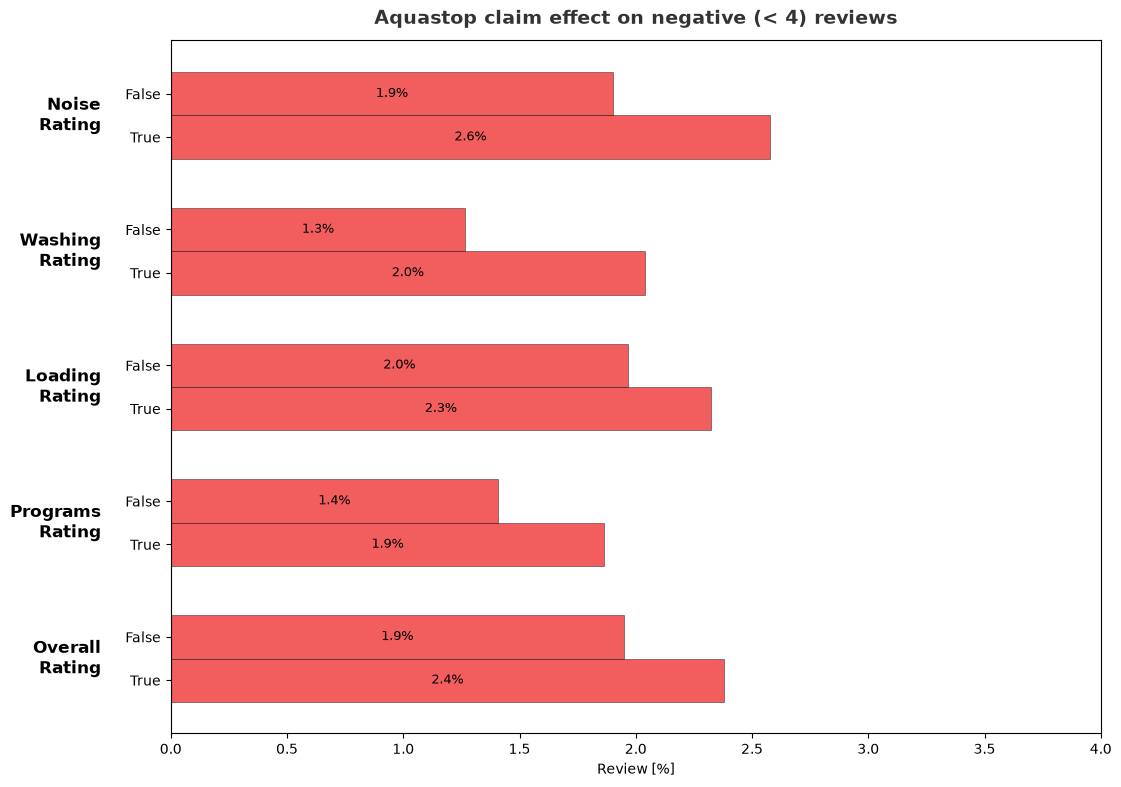

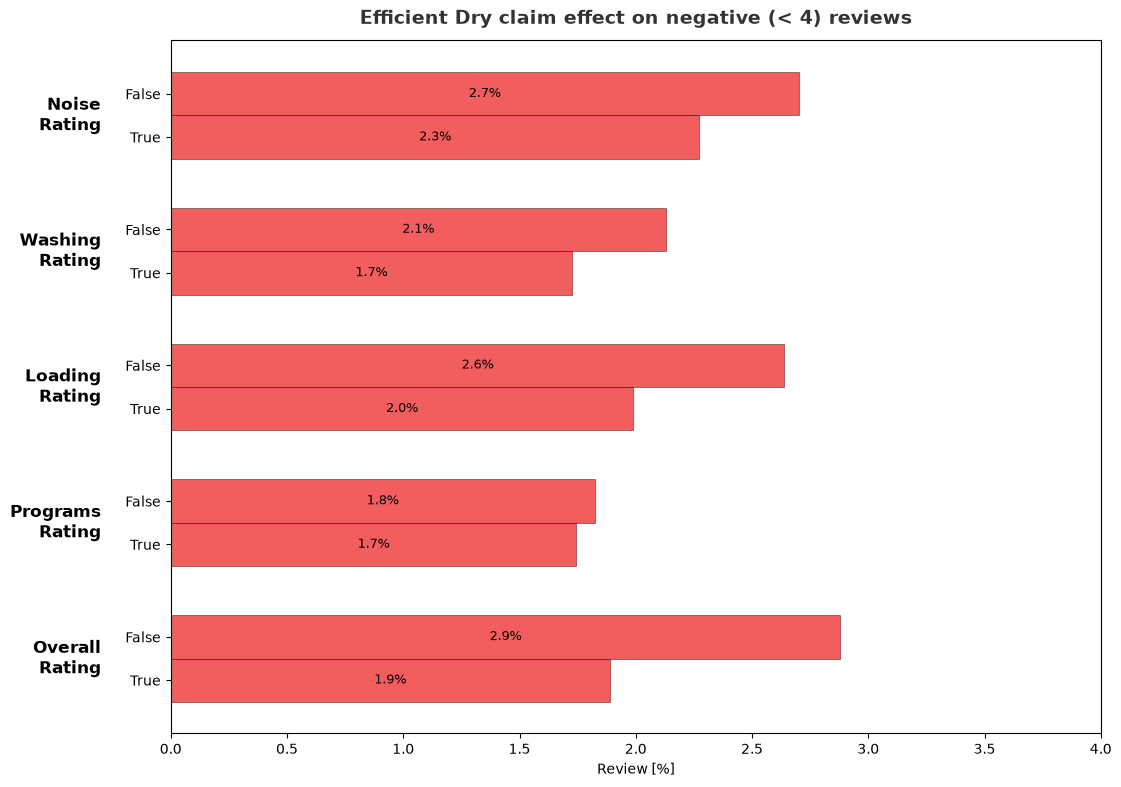

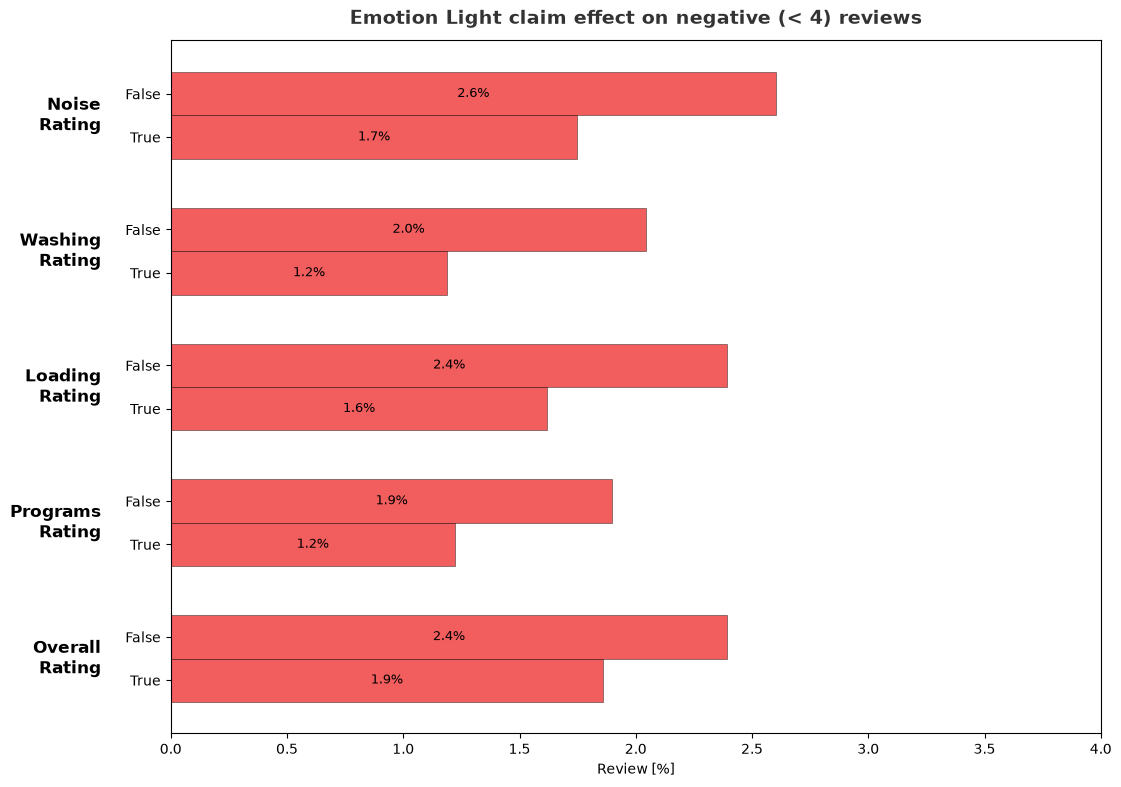

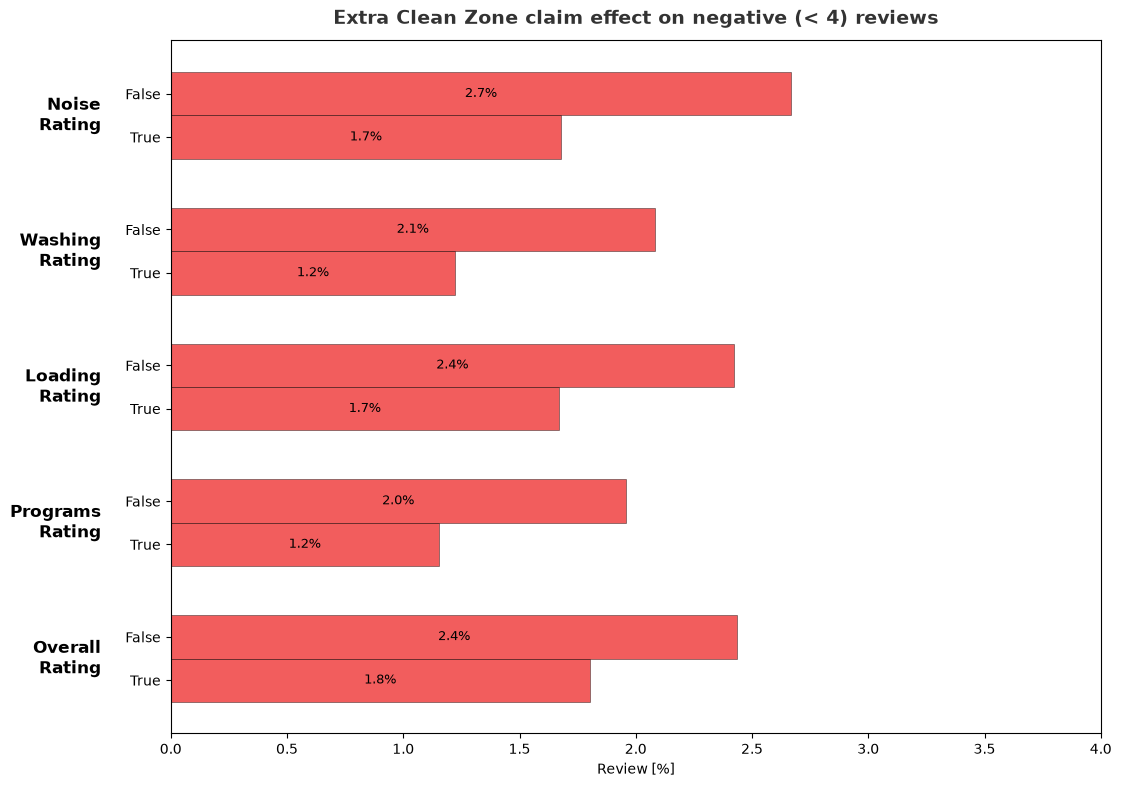

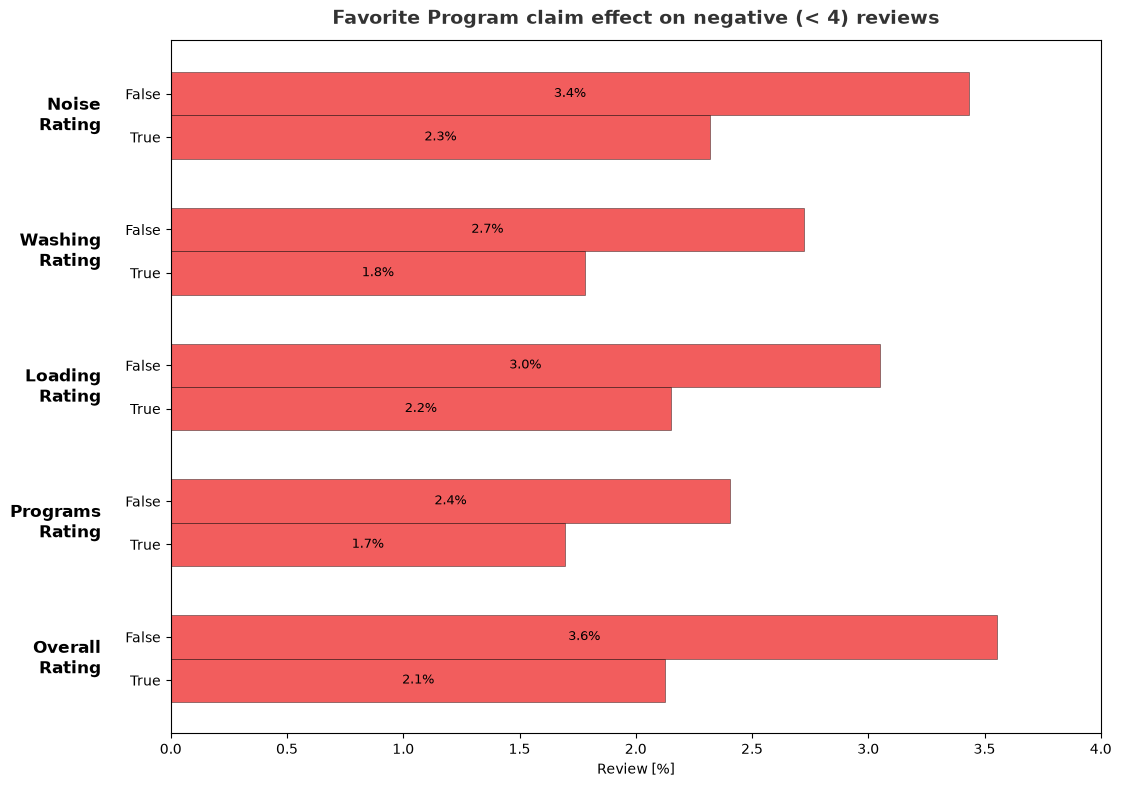

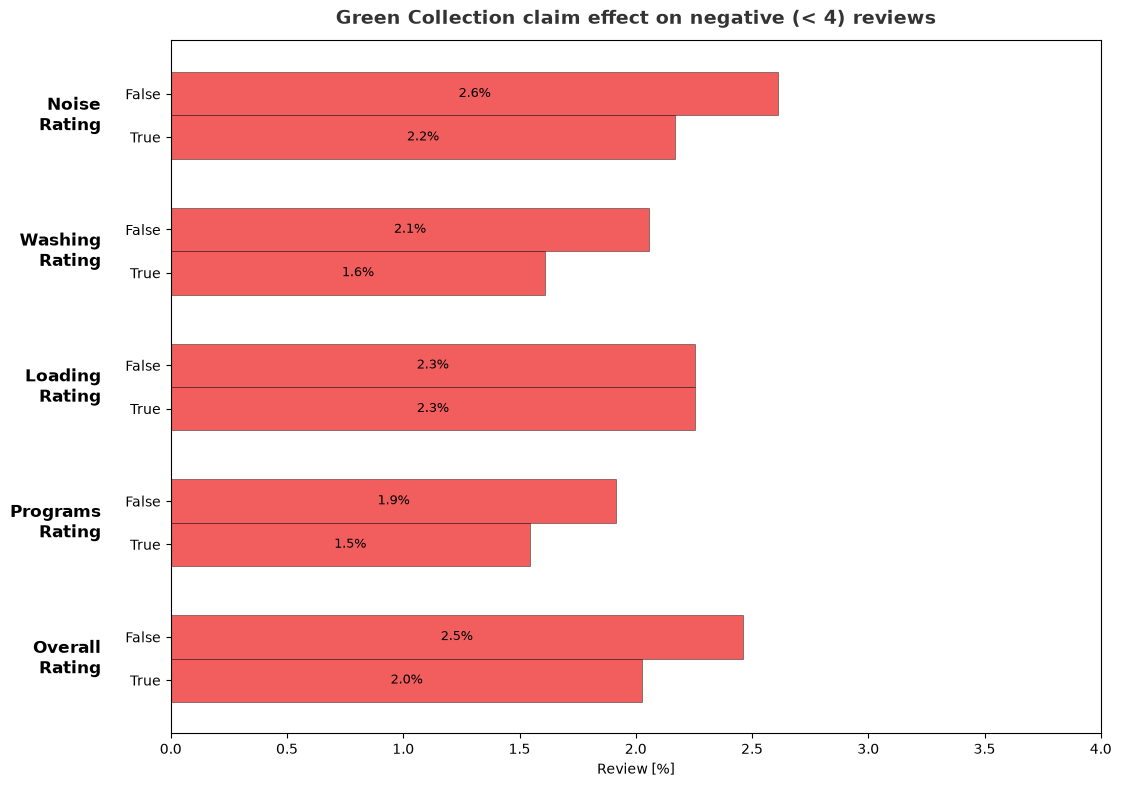

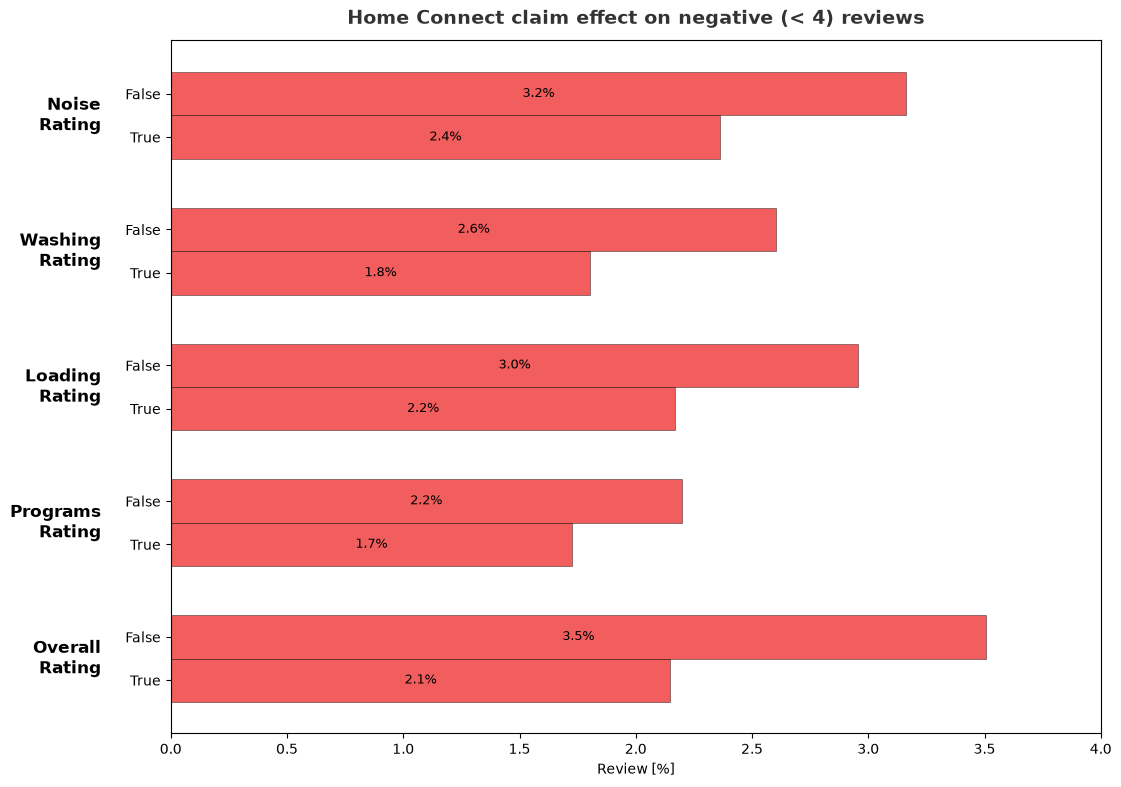

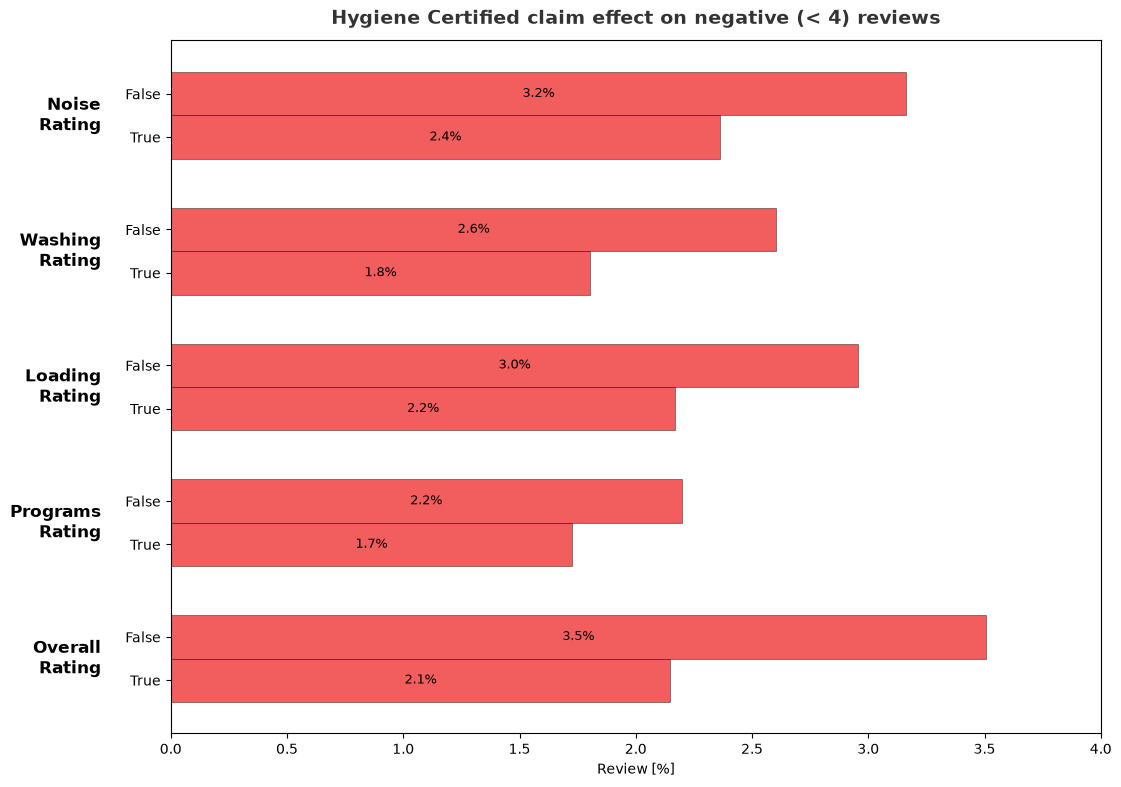

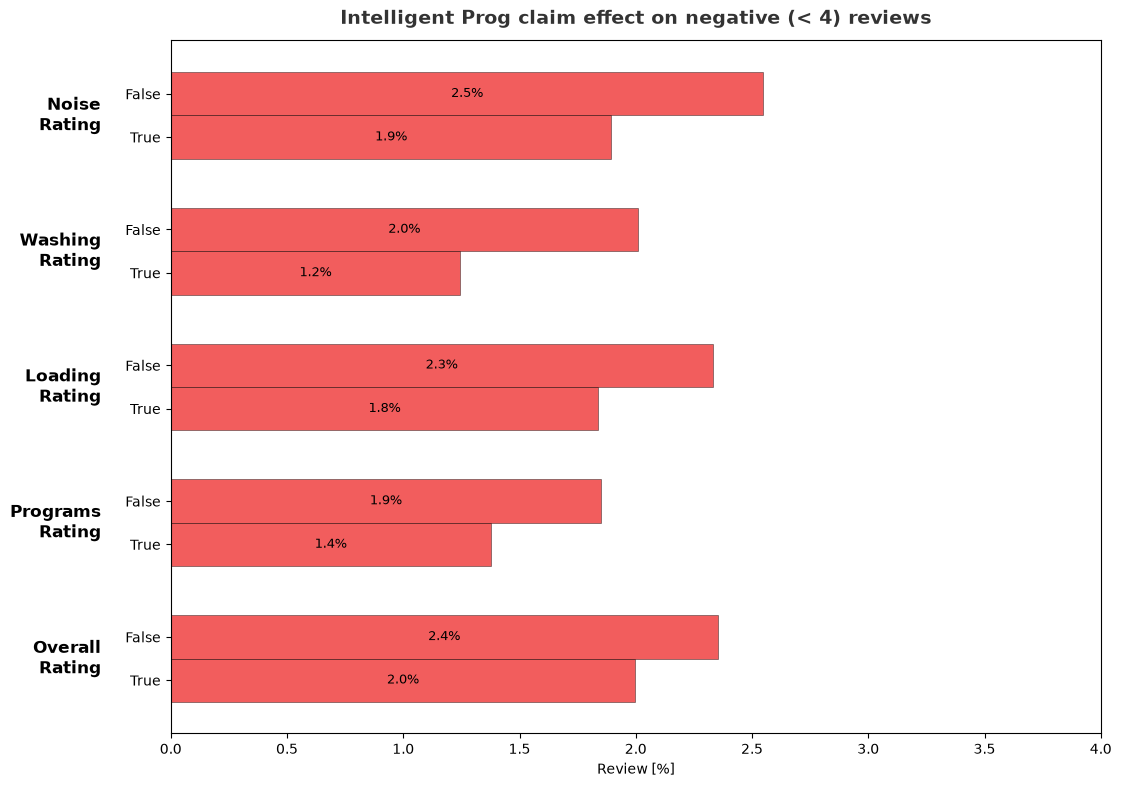

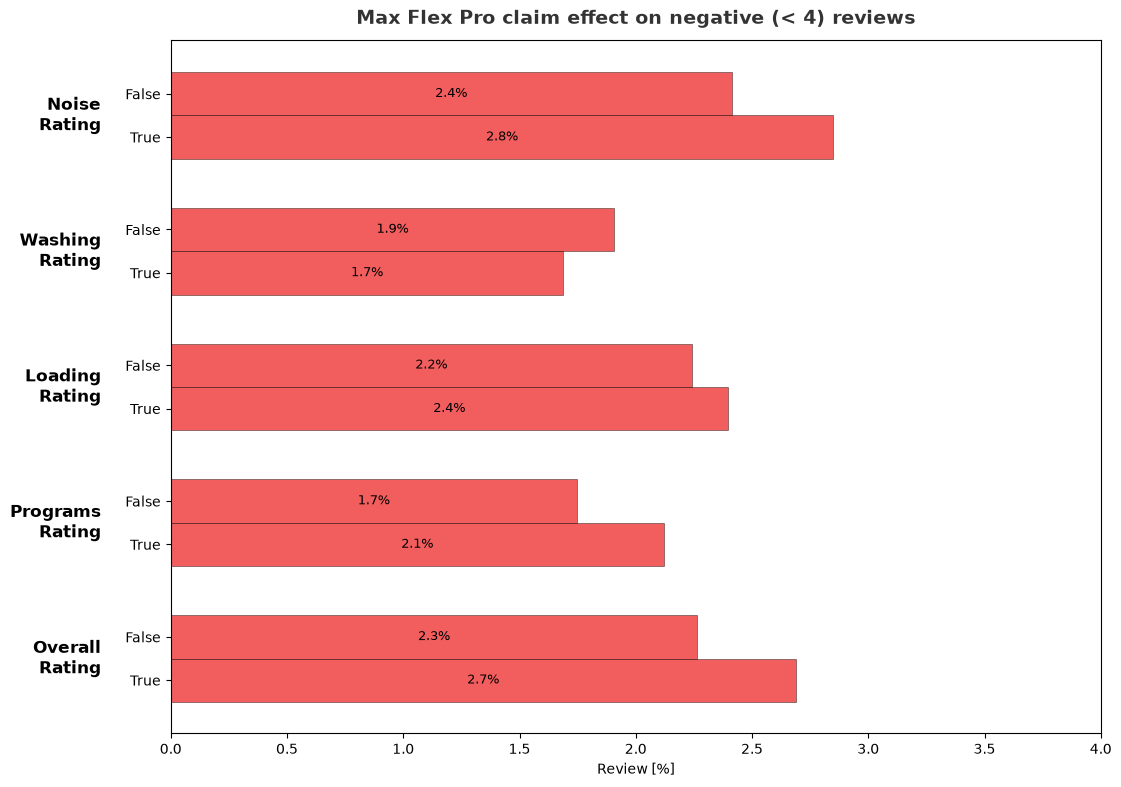

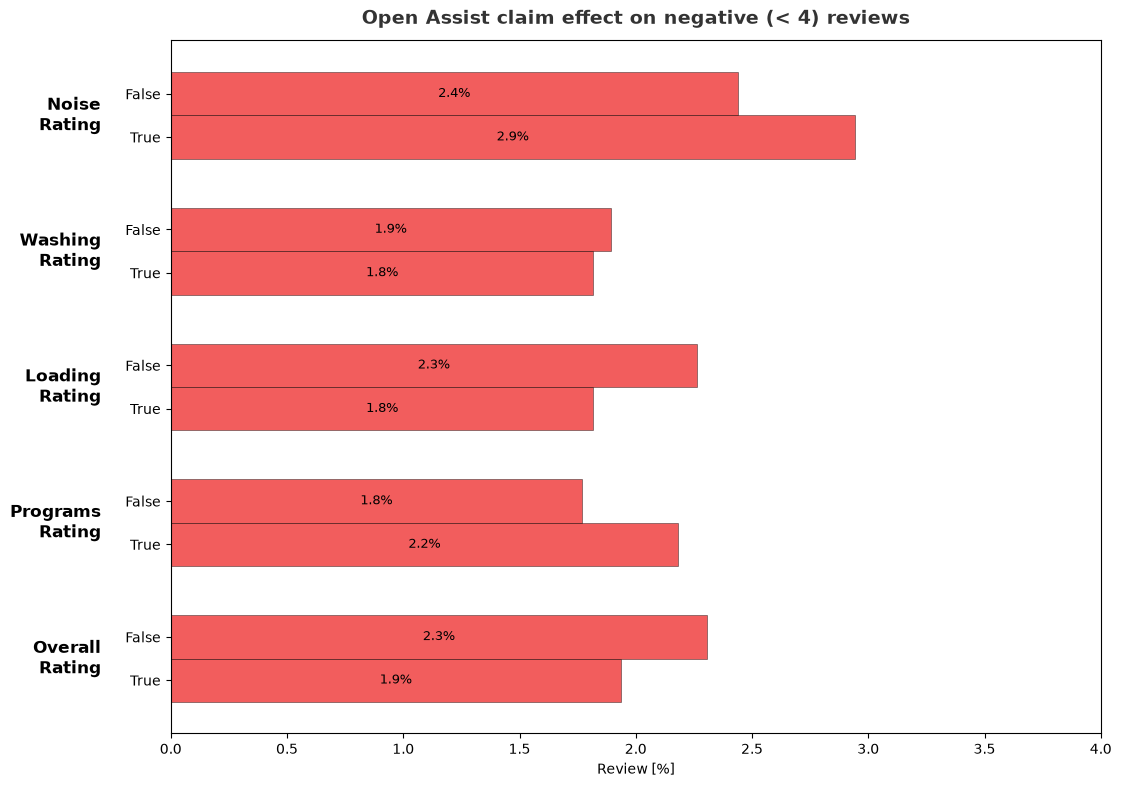

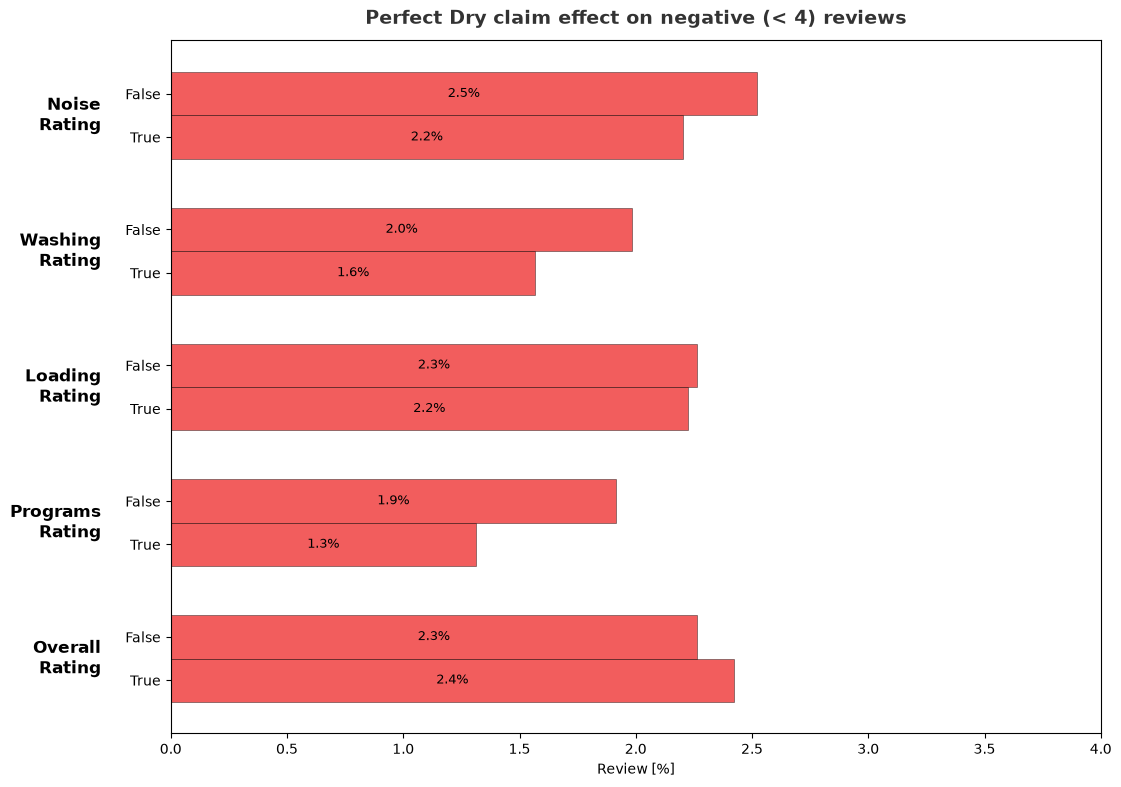

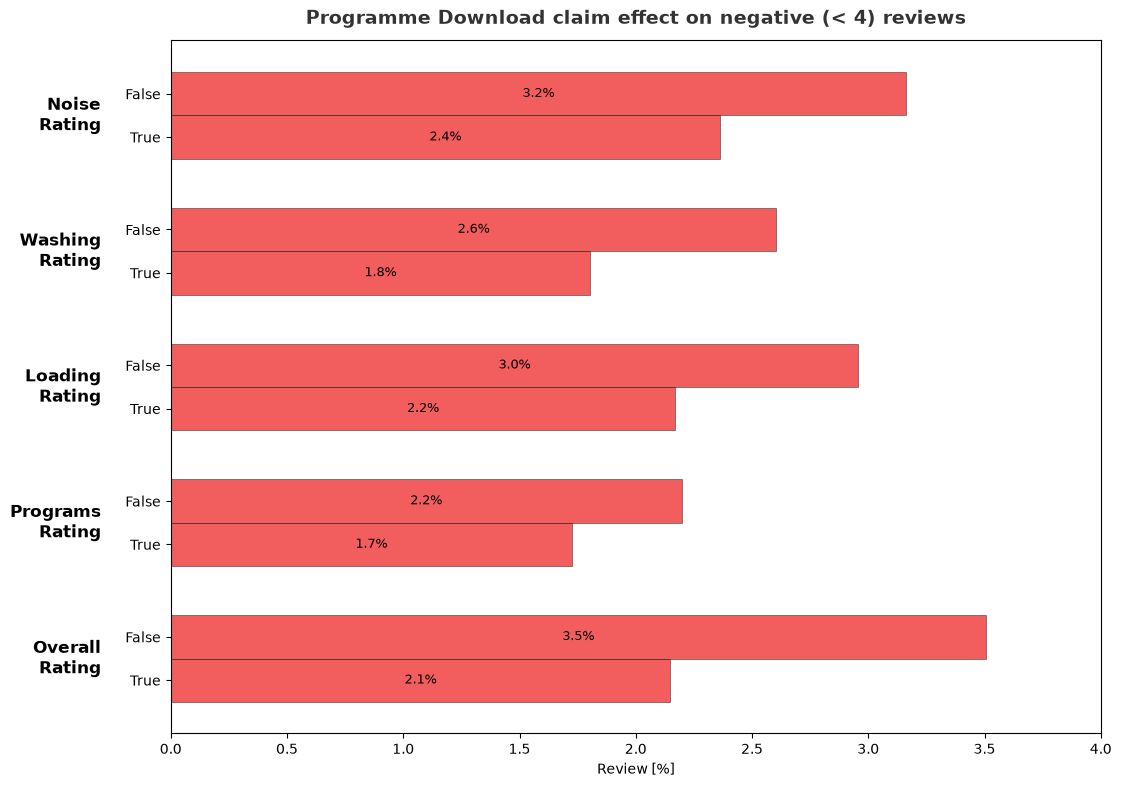

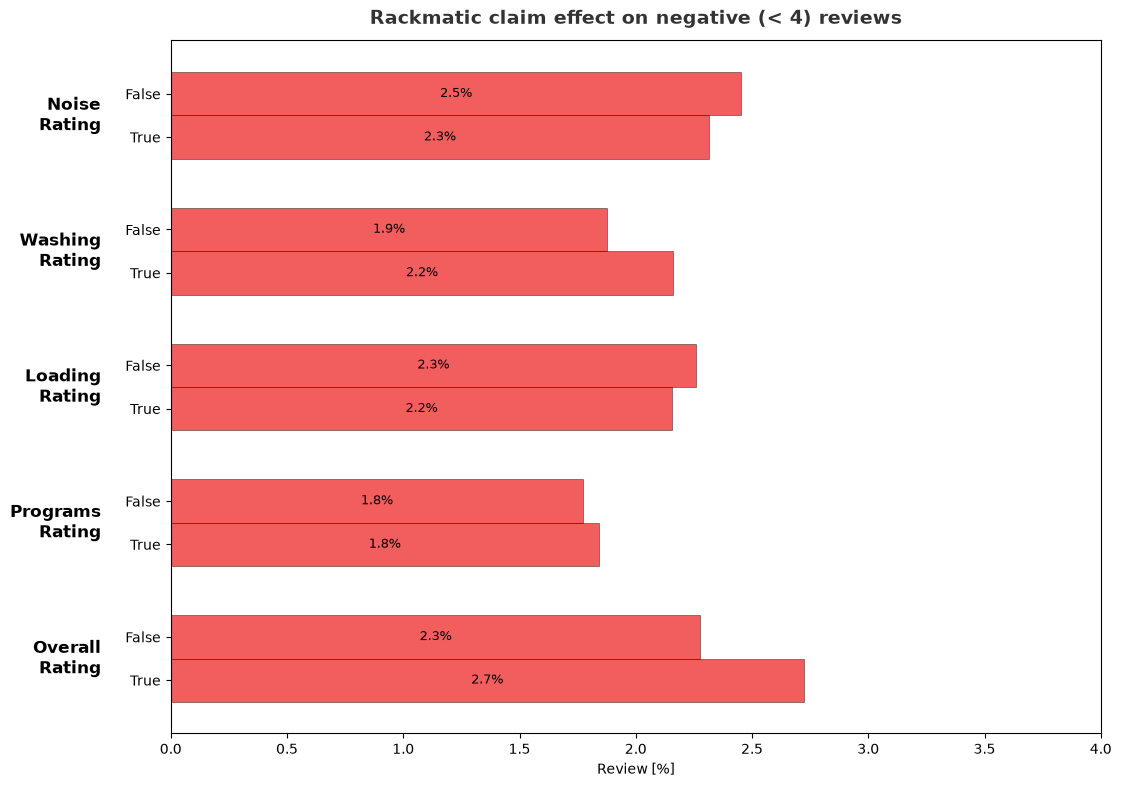

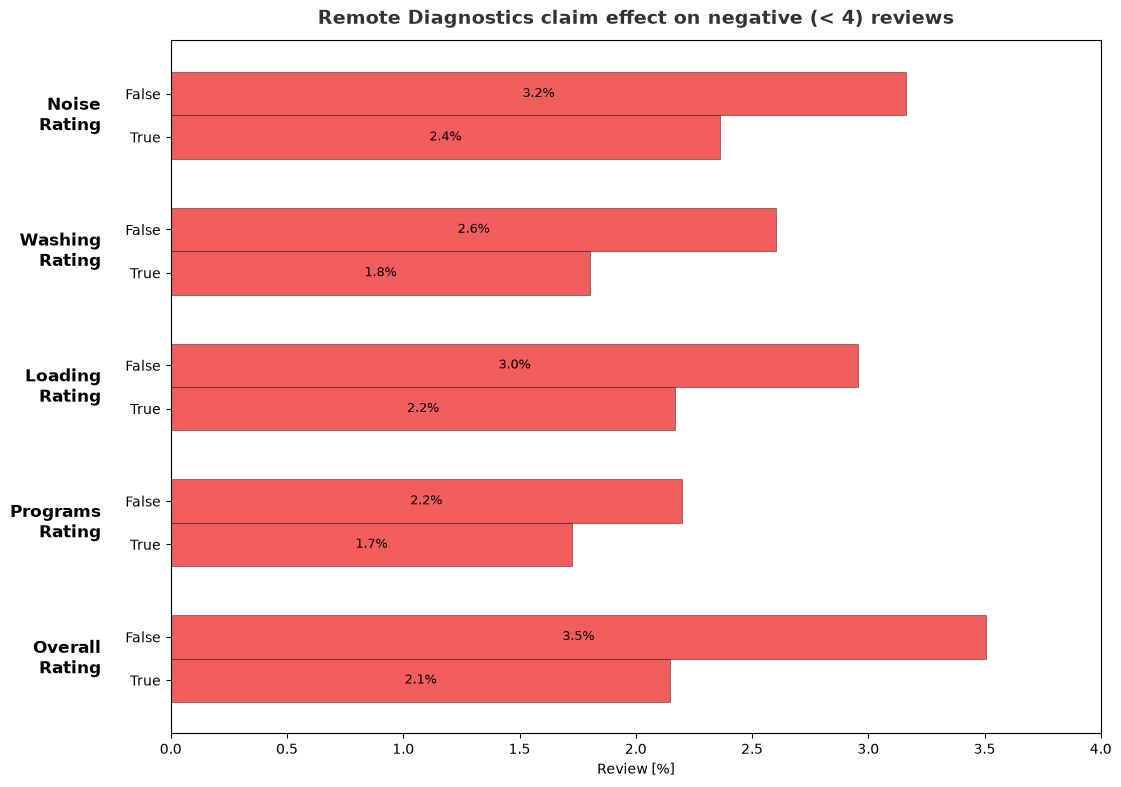

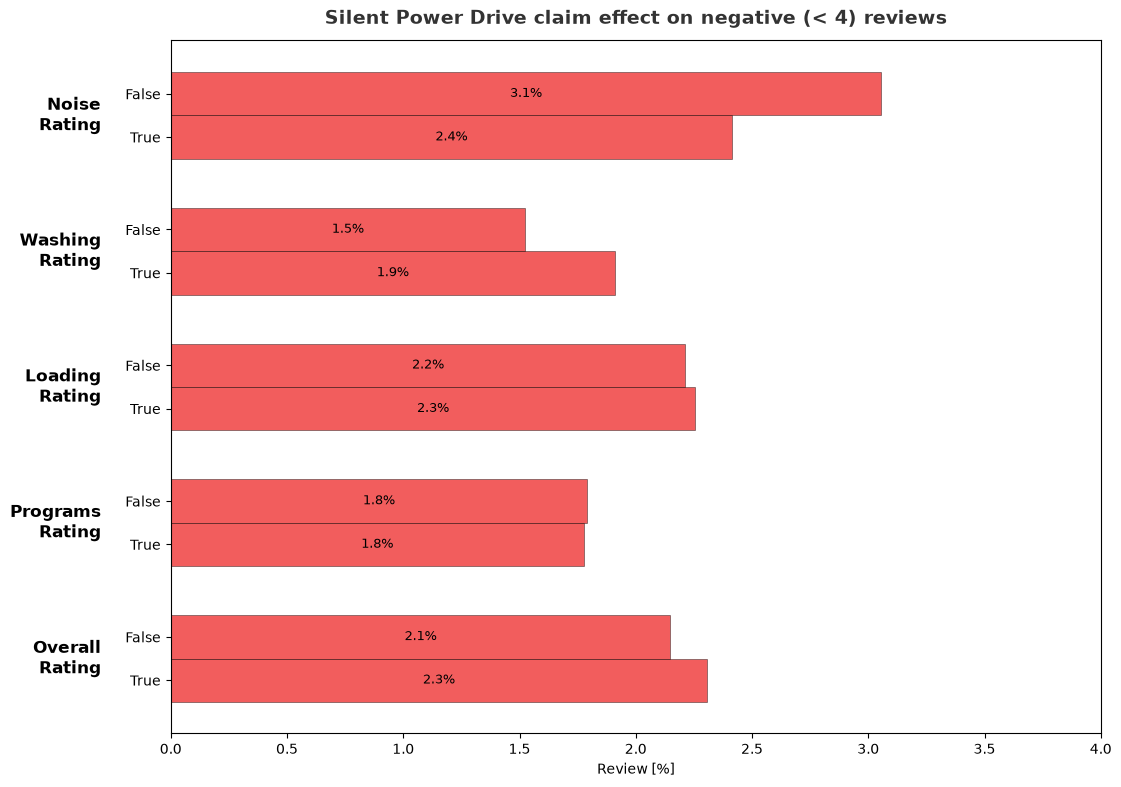

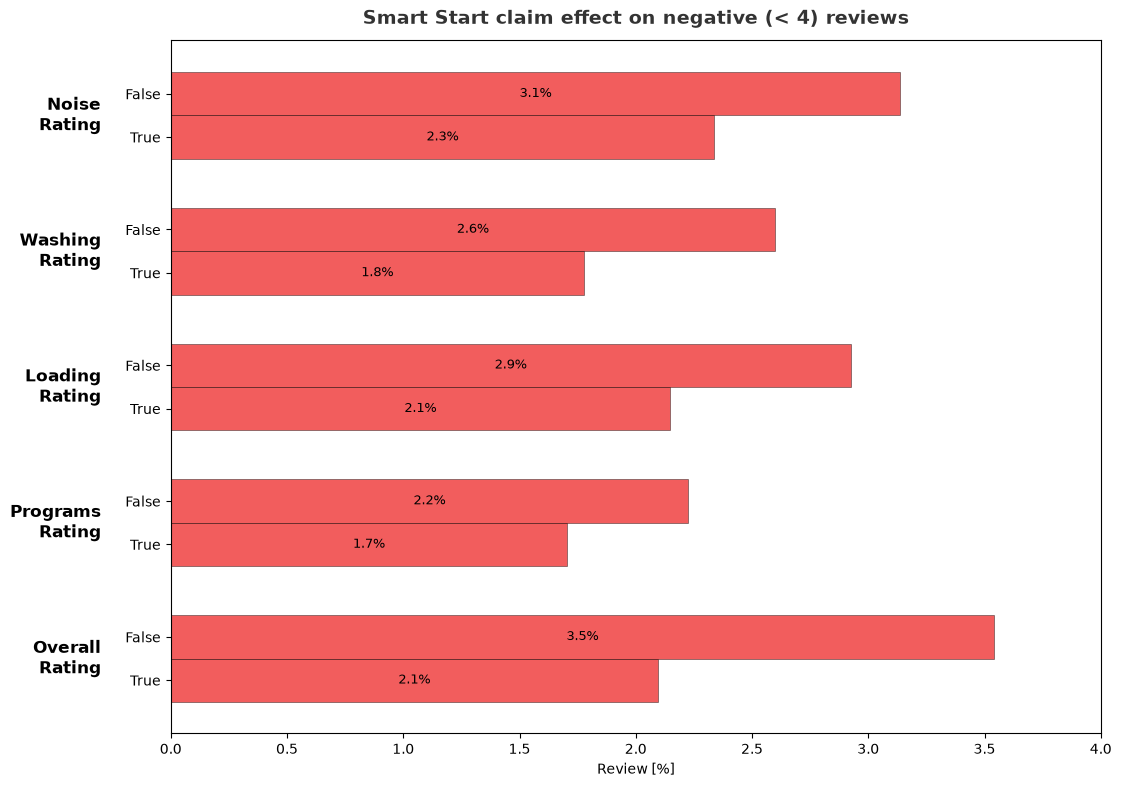

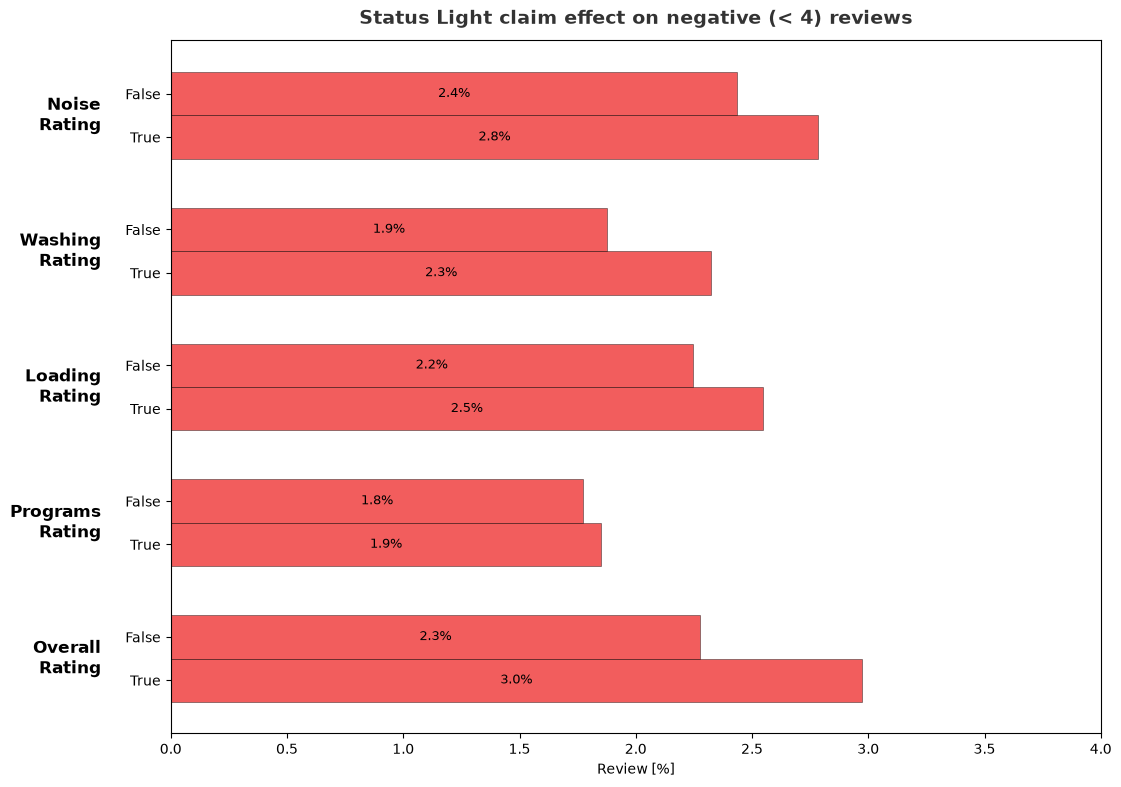

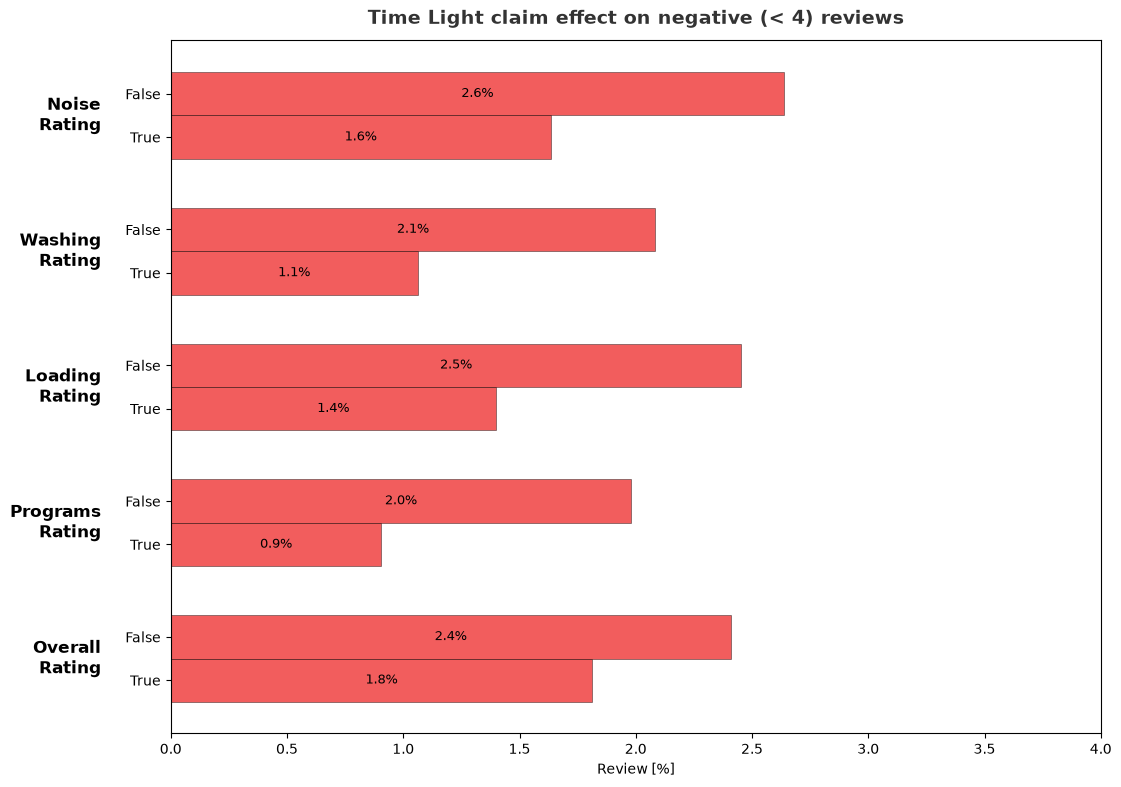

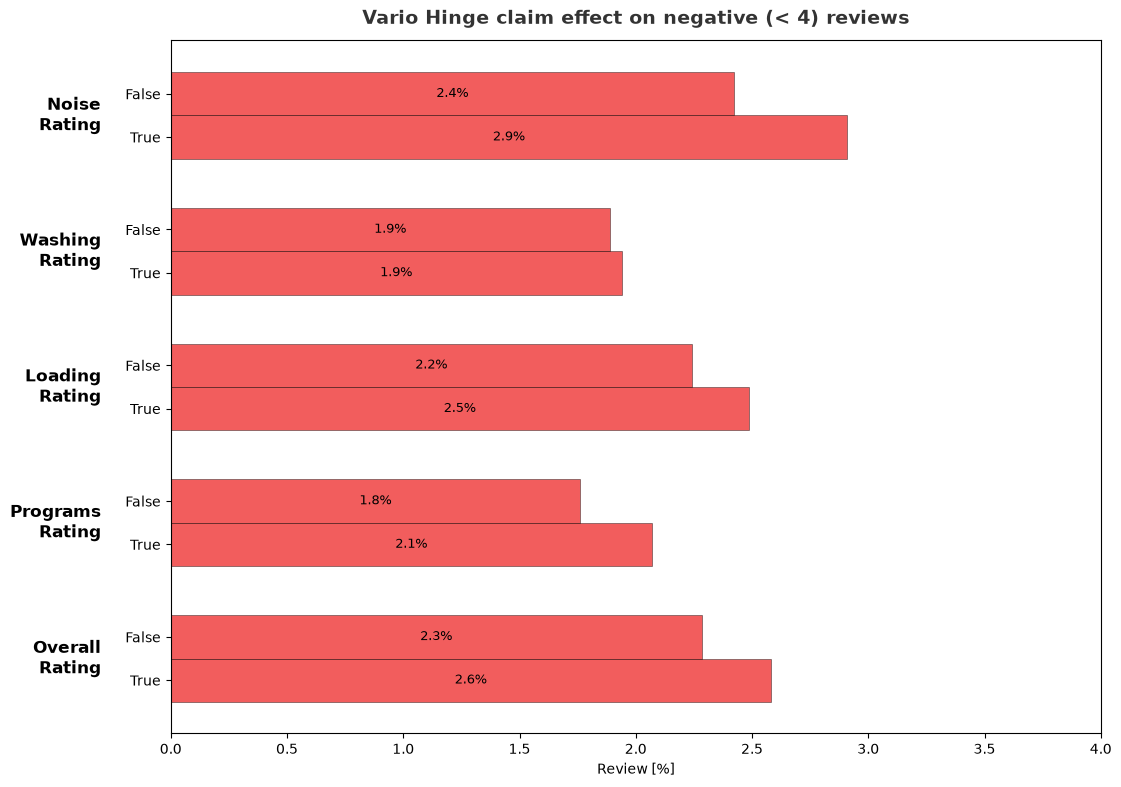

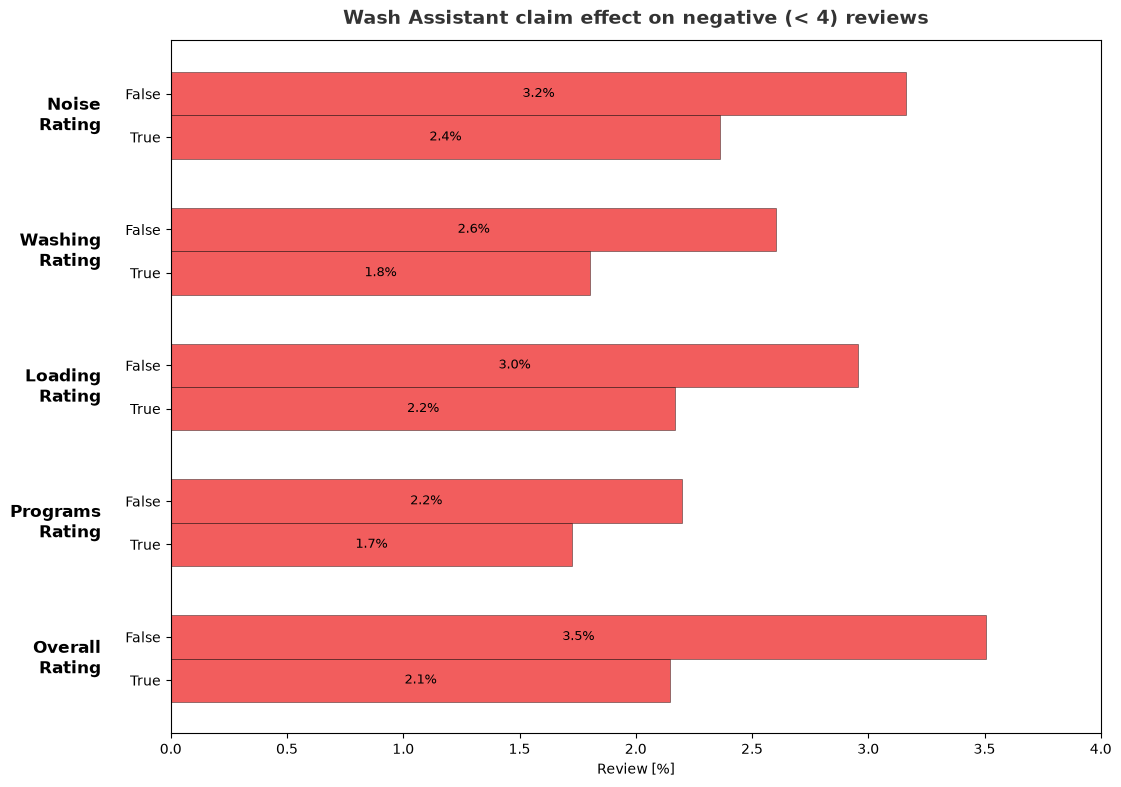

In [128]:
rating_cols = [
    "rating",
    "rating_programs",
    "rating_loading",
    "rating_washing",
    "rating_noise"
]

ratings = ", ".join(rating_cols)

RATING_DICT = {
    "rating": "Overall\nRating",
    "rating_programs": "Programs\nRating",
    "rating_loading": "Loading\nRating",
    "rating_washing": "Washing\nRating",
    "rating_noise": "Noise\nRating"
}

bar_h = 0.4
gap = 0.45

with sqlite3.connect(DB_PATH) as conn:
    cols = pd.read_sql("PRAGMA table_info(dim_product);", conn)

    claim_cols = cols.loc[
        cols["name"].str.startswith("has_") &
        (cols["name"] != "has_dosage_assist"),
        "name"
    ]

    for col in claim_cols:
        df = pd.read_sql(f"""
            SELECT {col}, {ratings}
            FROM fact_review JOIN dim_product ON fact_review.product_id = dim_product.product_id
            WHERE {col} IS NOT NULL 
        """, conn)

        df[col] = df[col].astype(bool)

        _, ax = plt.subplots(figsize=(12, 9))

        yticks = []
        ylabels = []

        for i, rcol in enumerate(rating_cols):

            base = i * (2 * bar_h + gap)

            for j, value in enumerate([True, False]):

                sub = df[df[col] == value]

                sub = sub[sub[rcol].notna()]
                low = (sub[rcol] < 4).mean() * 100

                y = base + j * bar_h

                ax.barh(
                    y,
                    low,
                    height=bar_h,
                    color=PLOT_COLOR_RED,
                    edgecolor="black",
                    linewidth=0.4,
                    alpha = 0.7
                )

                yticks.append(y)
                ylabels.append("True" if value else "False")

                ax.text(low/2, y, f"{low:.1f}%", ha="center", va="center", fontsize=9)

            ax.text(
                -0.3,
                base + bar_h / 2,
                RATING_DICT[rcol],
                ha="right",
                va="center",
                fontsize=12,
                fontweight="bold"
            )

        ax.set_xlim(0, 4)
        ax.set_xlabel("Review [%]")
        ax.set_yticks(yticks)
        ax.set_yticklabels(ylabels)

        title_string = f"{col[4:].replace("_"," ").title()} claim effect on negative (< 4) reviews"

        ax.set_title(title_string, fontsize=14, pad=12, color="#333", fontweight="bold")


